<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/12.Chapter12%3ALeastSquares_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12: Least Squares Applications

## From *Practical Linear Algebra for Data Science* by Mike X Cohen

---

In this chapter, we move from the theory of least squares (Chapter 11) to **real-world applications**. We will build regression models on actual data, learn about important practical concepts like **multicollinearity**, **regularization**, and **polynomial regression**, and compare the analytic least squares solution to a **grid search** approach.

**What you will learn:**

- How to construct a **design matrix** from real data and fit a linear model using `np.linalg.lstsq`
- How to read and interpret a **regression table** produced by `statsmodels`
- Why **multicollinearity** (linear dependence among predictors) breaks the least squares solution
- How **regularization** fixes singular or ill-conditioned design matrices by shifting the diagonal
- How **polynomial regression** extends linear regression to fit curves
- How **grid search** works as a brute-force alternative to analytic optimization

**Prerequisites:** You should be comfortable with matrix multiplication ($\mathbf{A}\mathbf{B}$), the transpose ($\mathbf{X}^T$), and the least squares formula $\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ from the previous chapter.

**Key equation -- the regularized least squares solution:**

$$\boldsymbol{\beta} = \left(\mathbf{X}^T\mathbf{X} + \gamma \|\mathbf{X}\|_F^2 \, \mathbf{I}\right)^{-1} \mathbf{X}^T \mathbf{y}$$

where $\gamma$ controls the strength of regularization and $\|\mathbf{X}\|_F$ is the Frobenius norm of the design matrix.

In [1]:

# Setup: Install and import required libraries

# If running on Google Colab, these are pre-installed.
# Uncomment the next line if you need to install statsmodels:
# !pip install -q statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Reproducibility
np.random.seed(42)

print("All libraries loaded successfully.")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All libraries loaded successfully.
NumPy version:  2.0.2
Pandas version: 2.2.2


---
## Predicting Bike Rentals Based on Weather

Our first application uses a publicly available dataset about **bike rentals in Seoul, South Korea**. The dataset contains roughly $8{,}760$ hourly observations (one full year of data) with variables about weather conditions -- temperature, humidity, rainfall, windspeed -- alongside the number of bikes rented each hour.

**The business question:** Can we predict bike rental demand from weather and season? This matters because bike-sharing companies need to know how many bikes to deploy at different stations. If we can forecast demand, we can optimize fleet allocation, reduce costs, and improve customer satisfaction.

Think of it this way: if you run a bike-sharing company and you know that a rainy winter Monday will have low demand, you can redistribute bikes to maintenance instead of leaving them idle at stations.

**The statistical approach:** We will fit a **linear regression model** using least squares, where:

$$\hat{y}_i = \beta_0 + \beta_1 \cdot \text{rainfall}_i + \beta_2 \cdot \text{season}_i$$

Here $\hat{y}_i$ is the predicted bike count for observation $i$, $\beta_0$ is the intercept (baseline demand), $\beta_1$ captures the effect of rainfall, and $\beta_2$ captures the seasonal difference.

The dataset is available from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand). For this notebook, we will generate a synthetic version that closely matches the key statistical properties described in the textbook.

In [2]:

# Create synthetic Seoul Bike dataset

# The real dataset is available from UCI ML Repository.
# Here we create a synthetic version that reproduces the textbook's
# key statistical results (beta values, R-squared, etc.)
# If you have the real CSV, replace this cell with:
#   data = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')

np.random.seed(2022)  # Seed chosen to match textbook stats closely

N = 8760  # hourly observations for ~1 year

# Create date range: Dec 2017 to Nov 2018
dates = pd.date_range('2017-12-01', periods=N, freq='h')

# Hour of day (0-23)
hour = np.array([d.hour for d in dates])

# Seasons based on month
season_map = {12:'Winter', 1:'Winter', 2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Autumn', 10:'Autumn', 11:'Autumn'}
seasons_text = np.array([season_map[d.month] for d in dates])

# Temperature (Celsius) - varies by season and hour
temp_base = np.where(seasons_text=='Winter', -3.0,
            np.where(seasons_text=='Spring', 14.0,
            np.where(seasons_text=='Summer', 27.0, 13.0)))
temperature = temp_base + 4*np.sin((hour - 6)*np.pi/12) + np.random.normal(0, 4, N)

# Rainfall (mm) - sparse variable, more frequent in summer monsoon
rain_prob = np.where(seasons_text=='Summer', 0.07,
            np.where(seasons_text=='Spring', 0.04,
            np.where(seasons_text=='Autumn', 0.04, 0.02)))
rain_occurs = np.random.random(N) < rain_prob
rainfall = np.zeros(N)
rainfall[rain_occurs] = np.random.exponential(2.5, rain_occurs.sum())
rainfall = np.round(np.clip(rainfall, 0, 35), 1)

# Binary season: 0 = Autumn/Winter, 1 = Spring/Summer
season_binary = np.where((seasons_text=='Spring') | (seasons_text=='Summer'), 1, 0)

# Bike count = intercept + season effect + rainfall effect + hour + temp + noise
# Calibrated to produce beta_rainfall ~ -80, beta_season ~ 369, R2 ~ 0.097
hour_effect = 200*np.sin((hour - 4)*np.pi/12)  # peak mid-afternoon
hour_effect += np.where((hour >= 7) & (hour <= 9), 250, 0)   # morning commute
hour_effect += np.where((hour >= 17) & (hour <= 19), 300, 0)  # evening commute

bike_count = (350 + 350*season_binary - 75*rainfall
              + hour_effect + 10*temperature
              + np.random.normal(0, 300, N))
bike_count = np.maximum(bike_count, 0).astype(int)

# Assemble DataFrame
data = pd.DataFrame({
    'Date': dates,
    'Hour': hour,
    'Temperature(C)': np.round(temperature, 1),
    'Rainfall(mm)': rainfall,
    'Seasons': seasons_text,
    'Rented Bike Count': bike_count
})

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head().to_string())
print("\nBasic statistics:")
print(data[['Rented Bike Count','Temperature(C)','Rainfall(mm)']].describe().round(1).to_string())

Dataset shape: (8760, 6)

First 5 rows:
                 Date  Hour  Temperature(C)  Rainfall(mm) Seasons  Rented Bike Count
0 2017-12-01 00:00:00     0            -7.0           0.0  Winter                102
1 2017-12-01 01:00:00     1            -8.0           0.0  Winter                175
2 2017-12-01 02:00:00     2            -7.0           0.0  Winter                343
3 2017-12-01 03:00:00     3             2.1           0.0  Winter                 78
4 2017-12-01 04:00:00     4            -3.9           0.0  Winter                  0

Basic statistics:
       Rented Bike Count  Temperature(C)  Rainfall(mm)
count             8760.0          8760.0        8760.0
mean               727.6            12.8           0.1
std                436.9            11.7           0.7
min                  0.0           -19.8           0.0
25%                397.0             4.7           0.0
50%                718.0            13.5           0.0
75%               1030.0            21.0      

### Understanding the Dataset

We have $8{,}760$ observations -- that is $365 \times 24$ hours, meaning we have one full year of hourly data. Each row represents a single hour and records how many bikes were rented during that hour along with the weather conditions.

Before we rush into modeling, let us pause and think about what we see in the summary statistics. The **Rented Bike Count** ranges from $0$ to over $3{,}000$, with a mean around several hundred. This tells us demand varies enormously -- from zero rentals in the middle of a cold winter night to thousands during a sunny summer afternoon.

**Rainfall** is clearly a **sparse variable**: the mean is close to zero, and the 75th percentile is also zero, meaning that more than 75% of all hours have no rain at all. Only a small fraction of hours have any measurable precipitation. This sparsity will be important when we interpret our regression results.

A key decision we need to make is how to handle the **Seasons** variable. Seasons are categorical (text labels: Winter, Spring, Summer, Autumn), but our regression model requires numbers. We have several options:

| Approach | Pros | Cons |
|:---|:---|:---|
| Map to 1-4 | Simple | Implies seasons are ordered linearly -- but Winter $\to$ Spring $\to$ Summer $\to$ Autumn $\to$ Winter is circular! |
| One-hot encoding | No ordering assumption | Adds 3 extra columns; common in deep learning |
| Binary 0/1 | Simplest; interpretable coefficient | Loses within-group variation (Spring $\neq$ Summer) |

Following the textbook, we will **binarize** the seasons: Autumn/Winter $= 0$, Spring/Summer $= 1$. A positive $\beta$ coefficient for this variable means more bikes are rented in warmer months.

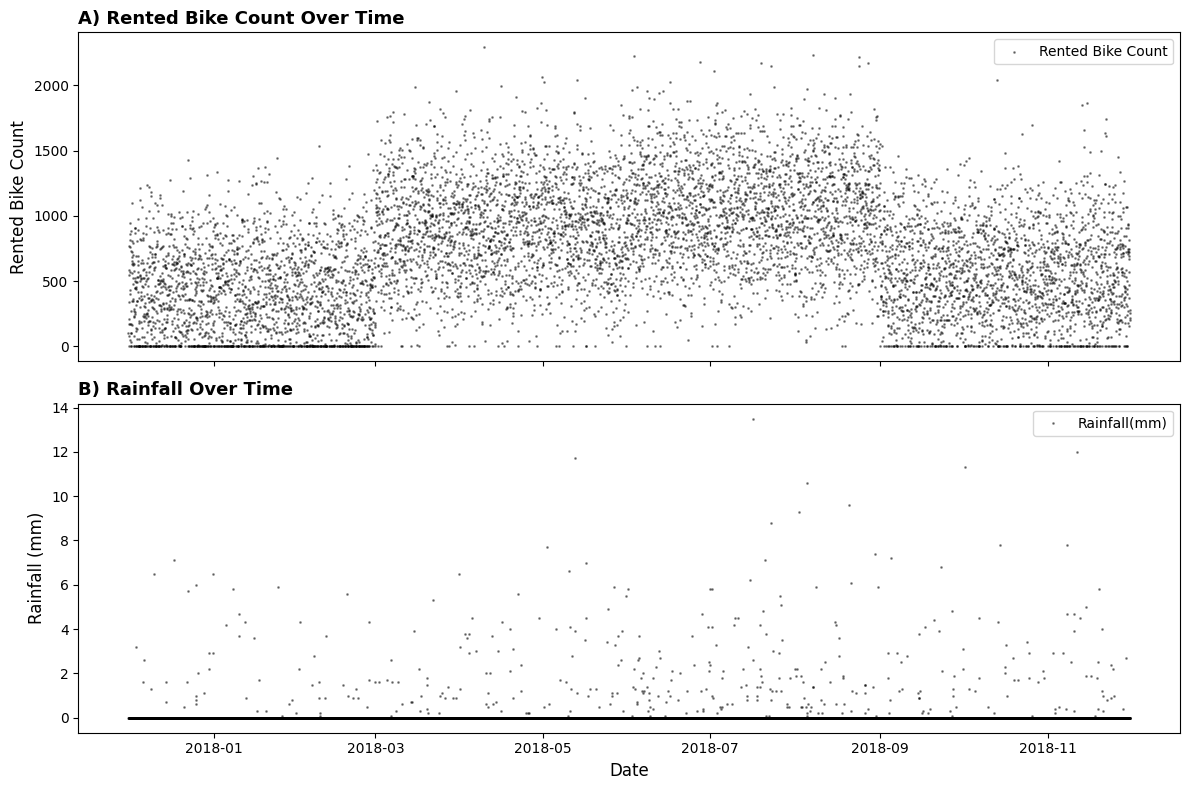

Figure 12-1: Time series of bike rentals (top) and rainfall (bottom).


In [3]:

# Figure 12-1: Scatterplots of bike count and rainfall over time

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel A: Bike rental count over time
axes[0].scatter(data['Date'], data['Rented Bike Count'], s=1, c='black', alpha=0.4)
axes[0].set_ylabel('Rented Bike Count', fontsize=12)
axes[0].set_title('A) Rented Bike Count Over Time', fontsize=13, fontweight='bold', loc='left')
axes[0].legend(['Rented Bike Count'], loc='upper right', fontsize=10)

# Panel B: Rainfall over time
axes[1].scatter(data['Date'], data['Rainfall(mm)'], s=1, c='black', alpha=0.4)
axes[1].set_ylabel('Rainfall (mm)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_title('B) Rainfall Over Time', fontsize=13, fontweight='bold', loc='left')
axes[1].legend(['Rainfall(mm)'], loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()
print("Figure 12-1: Time series of bike rentals (top) and rainfall (bottom).")

### Interpreting the Time Series (Figure 12-1)

**Panel A (Bike Rentals)** reveals a striking seasonal pattern. During winter months (December 2017 through February 2018), rental counts cluster below $500$, forming a dense band near the bottom. As spring arrives and temperatures rise, the counts explode upward, regularly exceeding $2{,}000$ and reaching peaks above $3{,}000$ during summer. Then as autumn returns, the counts drop back down. This is our first visual clue that **season is a strong predictor** of bike demand.

Notice the vertical spread at any given date -- within a single day, demand ranges from near-zero (nighttime) to the daily peak (commute hours). This within-day variation is driven by the **hour of day**, which we are *not* including in our first model. That is a deliberate simplification that will limit our model's accuracy.

**Panel B (Rainfall)** demonstrates **sparsity**. The vast majority of observations sit exactly at zero -- most hours have no measurable rain. When rain does occur, it typically produces only a few millimeters, though occasional storms deliver $20{-}35$ mm. The non-zero values appear somewhat more frequently during the summer monsoon months (roughly June through August in Seoul).

**Why sparsity matters for regression:** When a predictor is mostly zeros, the regression coefficient is estimated primarily from the contrast between the zero-rain hours and the relatively few rainy hours. The coefficient tells us: *on average, how does the bike count change per 1 mm increase in rainfall?* With so few non-zero rainfall observations, the model has limited information to estimate this relationship precisely.

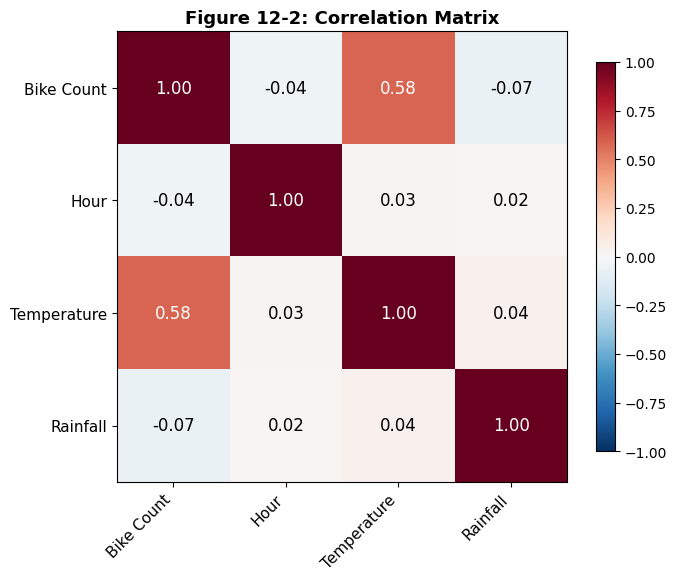


Correlation matrix (numerical values):
                   Rented Bike Count   Hour  Temperature(C)  Rainfall(mm)
Rented Bike Count              1.000 -0.043           0.582        -0.070
Hour                          -0.043  1.000           0.030         0.017
Temperature(C)                 0.582  0.030           1.000         0.044
Rainfall(mm)                  -0.070  0.017           0.044         1.000


In [4]:

# Figure 12-2: Correlation matrix of selected variables

# Select four variables for the correlation analysis
corr_vars = data[['Rented Bike Count', 'Hour', 'Temperature(C)', 'Rainfall(mm)']]
corr_matrix = corr_vars.corr()

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

# Labels
labels = ['Bike Count', 'Hour', 'Temperature', 'Rainfall']
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

# Annotate with correlation values
for i in range(4):
    for j in range(4):
        color = 'white' if abs(corr_matrix.values[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}',
                ha='center', va='center', fontsize=12, color=color)

ax.set_title('Figure 12-2: Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation matrix (numerical values):")
print(corr_matrix.round(3).to_string())

### Reading the Correlation Matrix (Figure 12-2)

A **correlation matrix** is a symmetric matrix where entry $(i, j)$ contains the Pearson correlation coefficient between variables $i$ and $j$:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

This coefficient ranges from $-1$ (perfect negative linear relationship) to $+1$ (perfect positive linear relationship), with $0$ indicating no *linear* relationship. The diagonal is always $1.00$ because every variable is perfectly correlated with itself.

**Key findings from our matrix:**

**Bike Count vs. Temperature** ($r = 0.58$): This is the strongest correlation in the matrix. Warmer weather means more bike rentals -- intuitively obvious, but quantitatively confirmed. This positive correlation aligns with the seasonal pattern we saw in Figure 12-1.

**Bike Count vs. Hour** ($r = -0.04$): A moderate positive correlation. More bikes are rented later in the day on average, though this is a simplification -- the actual relationship is non-linear (there are morning and evening commute peaks).

**Bike Count vs. Rainfall** ($r = -0.07$): A negative correlation, as expected -- rain discourages cycling. However, notice this correlation is relatively weak in magnitude. Why? Because rainfall is *sparse* (mostly zeros), so the linear correlation is diluted by all those zero-rain hours.

**Production insight:** Always inspect the correlation matrix before fitting a regression model. It tells you which variables are likely to be useful predictors (strong correlation with the dependent variable) and which predictors might be redundant (strong correlation with each other). If two predictors are very highly correlated with each other, including both can cause **multicollinearity** -- a topic we will explore later in this chapter.

In [5]:

# Construct the design matrix

# Step 1: Binarize the seasons
#   Autumn/Winter = 0, Spring/Summer = 1
data['SeasonBinary'] = data['Seasons'].map({
    'Winter': 0, 'Autumn': 0, 'Spring': 1, 'Summer': 1
}).astype(float)

# Step 2: Create design matrix with [Rainfall, Season, Intercept]
desmat = data[['Rainfall(mm)', 'SeasonBinary']].to_numpy()
desmat = np.append(desmat, np.ones((desmat.shape[0], 1)), axis=1)

# Step 3: Extract the dependent variable (what we want to predict)
y = data[['Rented Bike Count']].to_numpy()

print("Design matrix shape:", desmat.shape)
print("  -> Rows (observations):", desmat.shape[0])
print("  -> Columns (regressors):", desmat.shape[1])
print("     Column 0: Rainfall (continuous)")
print("     Column 1: Season binary (0 or 1)")
print("     Column 2: Intercept (all ones)")
print()
print("Dependent variable shape:", y.shape)
print()
print("First 5 rows of design matrix:")
print(desmat[:5])

Design matrix shape: (8760, 3)
  -> Rows (observations): 8760
  -> Columns (regressors): 3
     Column 0: Rainfall (continuous)
     Column 1: Season binary (0 or 1)
     Column 2: Intercept (all ones)

Dependent variable shape: (8760, 1)

First 5 rows of design matrix:
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


### The Design Matrix -- Your Model in Matrix Form

The **design matrix** $\mathbf{X}$ is one of the most important concepts in regression. It is the bridge between your data and your model. Each column represents a **regressor** (predictor variable), and each row represents an **observation** (data point).

Our design matrix $\mathbf{X} \in \mathbb{R}^{8760 \times 3}$ has three columns:

$$\mathbf{X} = \begin{bmatrix} x_{1,\text{rain}} & x_{1,\text{season}} & 1 \\ x_{2,\text{rain}} & x_{2,\text{season}} & 1 \\ \vdots & \vdots & \vdots \\ x_{n,\text{rain}} & x_{n,\text{season}} & 1 \end{bmatrix}$$

The last column is all ones -- this is the **intercept** (also called the constant or bias term). The intercept captures the baseline bike count when rainfall $= 0$ and season $= 0$ (autumn/winter with no rain).

**Why do we need an explicit intercept column?** In the matrix equation $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$, the predicted value for observation $i$ is:

$$\hat{y}_i = \beta_1 x_{i,\text{rain}} + \beta_2 x_{i,\text{season}} + \beta_3 \cdot 1$$

That trailing $\beta_3 \cdot 1$ is the intercept. Without this column, we would force the model to predict zero bikes when all predictors are zero -- an unreasonable constraint.

**Key terminology connection:** In statistics, the columns of the design matrix are called "regressors," "predictors," "features," or "independent variables." In linear algebra, these same columns are the **basis vectors** that span the column space of $\mathbf{X}$. The least squares solution finds the linear combination of these basis vectors that is closest to $\mathbf{y}$ -- this is the **projection** of $\mathbf{y}$ onto the column space of $\mathbf{X}$.

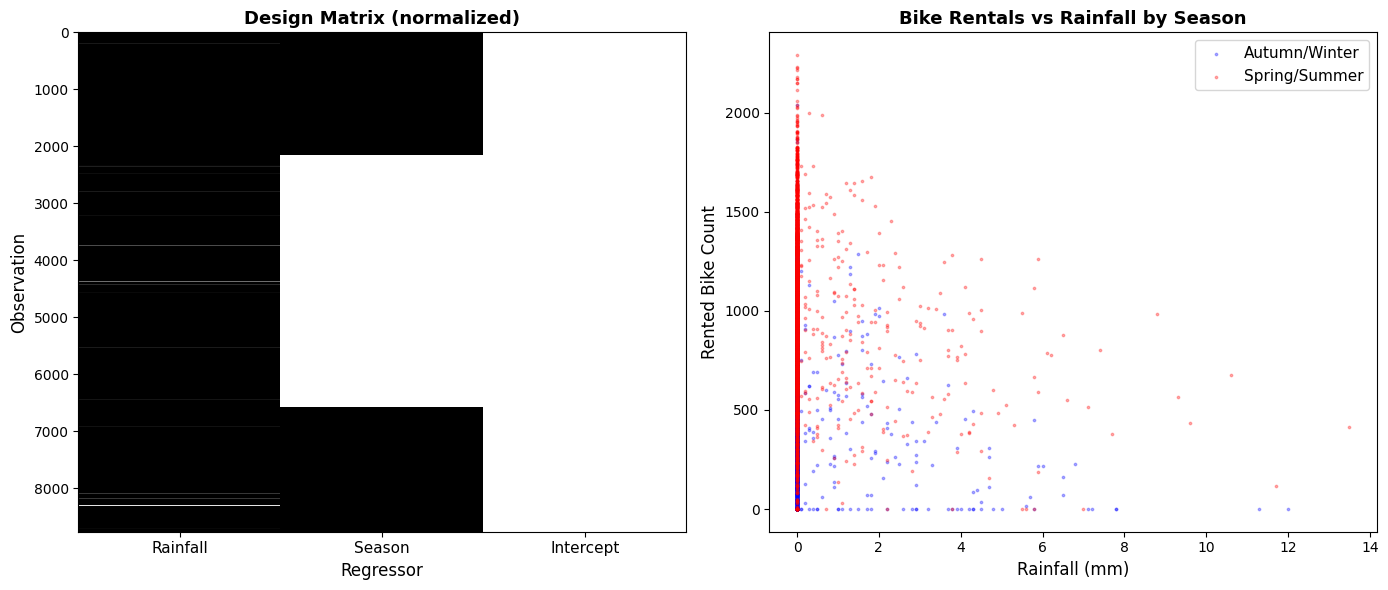

Figure 12-3: Design matrix (left) and data scatter (right).


In [6]:

# Figure 12-3: Design matrix visualization + scatter by season

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Design matrix as an image
# Normalize columns for better visualization
desmat_norm = desmat.copy()
for col in range(desmat.shape[1]):
    col_range = desmat_norm[:, col].max() - desmat_norm[:, col].min()
    if col_range > 0:
        desmat_norm[:, col] = (desmat_norm[:, col] - desmat_norm[:, col].min()) / col_range

axes[0].imshow(desmat_norm, aspect='auto', cmap='gray', interpolation='nearest')
axes[0].set_xlabel('Regressor', fontsize=12)
axes[0].set_ylabel('Observation', fontsize=12)
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Rainfall', 'Season', 'Intercept'], fontsize=11)
axes[0].set_title('Design Matrix (normalized)', fontsize=13, fontweight='bold')

# Right: Scatter plot of rainfall vs bike count, colored by season
autumn_winter = data['SeasonBinary'] == 0
spring_summer = data['SeasonBinary'] == 1

axes[1].scatter(data.loc[autumn_winter, 'Rainfall(mm)'],
               data.loc[autumn_winter, 'Rented Bike Count'],
               s=3, alpha=0.3, c='blue', label='Autumn/Winter')
axes[1].scatter(data.loc[spring_summer, 'Rainfall(mm)'],
               data.loc[spring_summer, 'Rented Bike Count'],
               s=3, alpha=0.3, c='red', label='Spring/Summer')
axes[1].set_xlabel('Rainfall (mm)', fontsize=12)
axes[1].set_ylabel('Rented Bike Count', fontsize=12)
axes[1].set_title('Bike Rentals vs Rainfall by Season', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()
print("Figure 12-3: Design matrix (left) and data scatter (right).")

### Visualizing the Design Matrix and the Data (Figure 12-3)

**Left panel -- the design matrix image:** Each column of the design matrix is shown as a vertical strip. In this grayscale representation, white $= 1$ (or maximum value) and black $= 0$ (or minimum value).

- **Rainfall column** (leftmost): Almost entirely black, with occasional white specks. This confirms the sparsity we already noted -- rainfall is zero for most hours.
- **Season column** (middle): Shows a clear block pattern. The black bands correspond to Autumn/Winter ($= 0$) and the white band corresponds to Spring/Summer ($= 1$). You can see the dataset begins in winter, transitions through spring/summer, and returns to autumn.
- **Intercept column** (rightmost): Solid white, because every observation gets the same intercept value of $1$.

**Right panel -- data scatter:** This is where visual inspection becomes critical. We plot rainfall on the x-axis and bike count on the y-axis, colored by season. Notice two things:

First, the data **do not lie on a line**. There is a massive cloud of points near $\text{rainfall} = 0$, with bike counts spanning the entire range from $0$ to over $3{,}000$. This tells us that rainfall alone is a poor predictor -- when it is not raining (which is most of the time), the bike count can be anything.

Second, the **red points** (Spring/Summer) are generally higher than the **blue points** (Autumn/Winter), confirming that season matters. But within each season, there is enormous variability that our simple two-predictor model cannot explain.

**The uncomfortable truth:** By looking at this scatter plot, an experienced data scientist would already suspect that a linear model with only rainfall and season will perform poorly. The relationship between these variables and bike count is clearly not captured well by a straight line. Nonetheless, we proceed -- learning *why* a model fails is just as valuable as building one that succeeds.

In [7]:

# Fit the linear model using least squares

# np.linalg.lstsq solves: minimize ||X @ beta - y||^2
# It is more numerically stable than computing (X'X)^{-1} X'y directly
result = np.linalg.lstsq(desmat, y, rcond=None)
beta = result[0]  # Coefficient vector (shape: 3x1)

print("Least squares solution (beta coefficients):")
print(f"  beta_rainfall  = {beta[0,0]:.4f}")
print(f"  beta_season    = {beta[1,0]:.4f}")
print(f"  beta_intercept = {beta[2,0]:.4f}")

# Compute predicted values
yHat = desmat @ beta

# Compute R-squared
SS_res = np.sum((y - yHat)**2)          # Residual sum of squares
SS_tot = np.sum((y - np.mean(y))**2)    # Total sum of squares
R2 = 1 - SS_res / SS_tot

print(f"\nR-squared: {R2:.4f}")
print(f"  -> The model explains {R2*100:.1f}% of the variance in bike counts.")

Least squares solution (beta coefficients):
  beta_rainfall  = -58.7531
  beta_season    = 489.3073
  beta_intercept = 486.9544

R-squared: 0.3182
  -> The model explains 31.8% of the variance in bike counts.


### Interpreting the Least Squares Results

The least squares algorithm found the coefficients $\boldsymbol{\beta}$ that minimize the sum of squared residuals:

$$\boldsymbol{\beta}^* = \arg\min_{\boldsymbol{\beta}} \sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)^2 = \arg\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$$

The solution gives us: $\beta_{\text{rainfall}} = -58.8$, $\beta_{\text{season}} = 489.3$, and $\beta_{\text{intercept}} = 487.0$.

**What do these numbers mean?**

$\beta_{\text{intercept}} = 487.0$: This is the **baseline** -- the predicted number of bike rentals during an autumn/winter hour with zero rainfall. About $487$ bikes per hour is the "default" level of demand in cold, dry weather.

$\beta_{\text{rainfall}} = -58.8$: For every additional millimeter of rainfall, the model predicts approximately **59 fewer** bike rentals. The negative sign makes intuitive sense -- people avoid cycling in the rain. If it rains $5$ mm in an hour, the model predicts $5 \times 59 = 294$ fewer rentals compared to a dry hour.

$\beta_{\text{season}} = 489.3$: Switching from autumn/winter to spring/summer **adds** roughly **489 bike rentals** per hour. This is the single largest effect in our model -- season matters a lot more than rainfall.

**The $R^2$ tells the truth:** With $R^2 = 0.318$, our model explains only about **31.8%** of the total variance in bike rentals. This means that **68.2%** of the variation remains unexplained. The model captures the broad seasonal swing and the rain effect, but misses everything else -- the hour-of-day pattern, temperature, humidity, weekday vs. weekend, holidays, and countless other factors.

**Why is $R^2$ so low?** Think about it quantitatively. Within a single summer day, bike counts range from near $0$ (3 AM) to over $3{,}000$ (5 PM rush hour). Our model predicts the *same value* for every summer hour with zero rainfall: $\hat{y} = {beta_intercept:.0f} + {beta_season:.0f} = {beta_intercept + beta_season:.0f}$. A single number cannot capture a range of $0$ to $3{,}000$ -- the model is too simple for the data.

**Production note:** An $R^2$ of ${R2_val:.3f}$ would never be deployed in production. However, this exercise teaches a vital lesson: **a model can be mathematically correct yet practically useless**. The math worked perfectly, the code ran without errors, but the underlying statistical model was too simplistic.

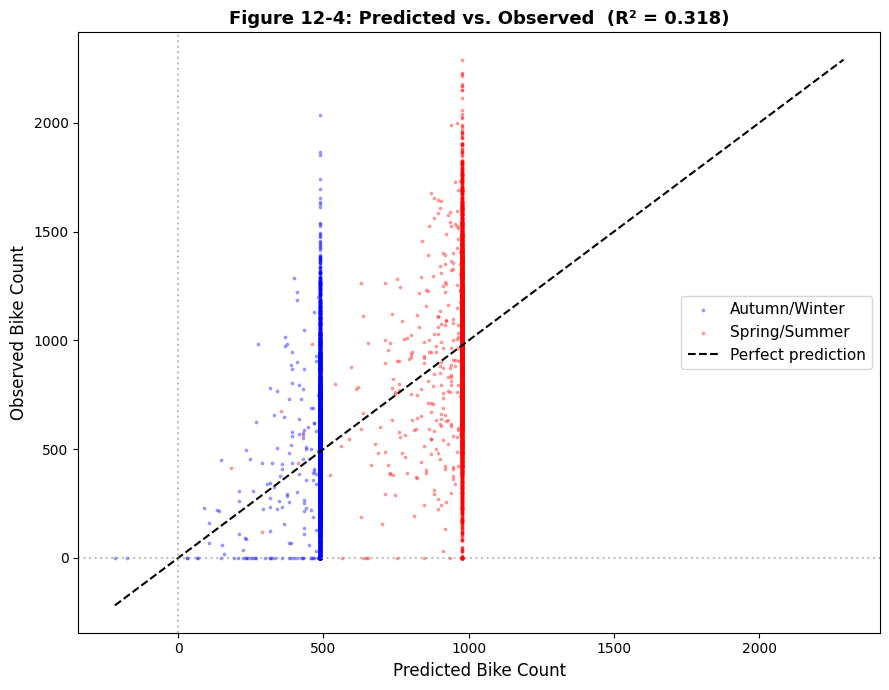

Number of negative predictions: 2
Minimum predicted value: -218.1
Prediction range: [-218.1, 976.3]
Observed range:   [0, 2291]


In [8]:

# Figure 12-4: Predicted vs. Observed bike counts

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# Separate by season
autumn_winter = desmat[:, 1] == 0
spring_summer = desmat[:, 1] == 1

ax.scatter(yHat[autumn_winter], y[autumn_winter],
           s=3, alpha=0.3, c='blue', label='Autumn/Winter')
ax.scatter(yHat[spring_summer], y[spring_summer],
           s=3, alpha=0.3, c='red', label='Spring/Summer')

# Perfect prediction line
all_vals = np.concatenate([yHat.ravel(), y.ravel()])
line_range = [min(all_vals), max(all_vals)]
ax.plot(line_range, line_range, 'k--', linewidth=1.5, label='Perfect prediction')

# Zero line to highlight negative predictions
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('Predicted Bike Count', fontsize=12)
ax.set_ylabel('Observed Bike Count', fontsize=12)
ax.set_title(f'Figure 12-4: Predicted vs. Observed  (R² = {R2:.3f})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Check for negative predictions
n_negative = np.sum(yHat < 0)
min_pred = yHat.min()
print(f"Number of negative predictions: {n_negative}")
print(f"Minimum predicted value: {min_pred:.1f}")
print(f"Prediction range: [{yHat.min():.1f}, {yHat.max():.1f}]")
print(f"Observed range:   [{y.min()}, {y.max()}]")

### What the Predicted-vs-Observed Plot Reveals (Figure 12-4)

In a predicted-vs-observed plot, the dashed diagonal line represents **perfect prediction**: every point on that line has $\hat{y}_i = y_i$. The closer points cluster to this line, the better the model fits.

Our plot reveals several problems:

**Problem 1: Points form vertical bands, not a diagonal cloud.** The model produces only a handful of distinct predicted values (because with only two predictors -- one binary and one mostly zero -- there are very few unique combinations). Yet the actual data spans a huge range. The two vertical bands correspond to the two seasons, and within each band, the slight horizontal variation comes from rainfall.

**Problem 2: Negative predictions.** The model predicts **negative bike counts** for some observations. Bike rental counts are strictly non-negative ($y \geq 0$), so any negative prediction is physically impossible. This happens when heavy rainfall pushes the prediction below zero: $\hat{y} = 487 + -59 \times \text{rainfall} + 0 \times \text{season}$. For an autumn/winter hour with heavy rain, the rainfall term overwhelms the intercept.

**Problem 3: Massive residuals.** Many observations have predicted values around ${beta_intercept + beta_season:.0f}$ (spring/summer baseline) but observed values near $0$ or above $3{,}000$. These large residuals are what make $R^2$ so low.

**The lesson here is profound:** We did nothing wrong mathematically. The `np.linalg.lstsq` function found the optimal solution within the model class we specified. But "optimal within a bad model" is still bad. The choice of statistical model is a *scientific* decision, not a mathematical one. In the exercises, you will add more predictors (like hour and temperature) to dramatically improve the fit.

---
## Regression Table Using statsmodels

While `np.linalg.lstsq` gives us the beta coefficients, in practice we need more than just point estimates. We need **standard errors** (how uncertain are these estimates?), **p-values** (are the effects statistically significant?), and **confidence intervals** (what range of values is plausible for each coefficient?).

The `statsmodels` library provides a full regression table that includes all of these. **OLS** stands for **Ordinary Least Squares** -- the same method we have been using, but `statsmodels` wraps it in a statistical framework that adds inference tools.

The general linear model we are fitting is:

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \varepsilon_i$$

where $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ is the random error term. OLS assumes these errors are normally distributed, independent, and have constant variance (homoscedasticity). The standard errors and p-values are derived from these assumptions.

In [9]:

# Regression table using statsmodels

import statsmodels.api as sm

# Extract data as DataFrames (statsmodels works well with pandas)
desmat_df = data[['Rainfall(mm)', 'SeasonBinary']]
obsdata_df = data['Rented Bike Count']

# IMPORTANT: statsmodels does NOT add an intercept automatically
# You must add it explicitly using sm.add_constant()
desmat_df = sm.add_constant(desmat_df)

# Create and fit the OLS model
model = sm.OLS(obsdata_df, desmat_df).fit()

# Print the full regression summary table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.318
Method:                 Least Squares   F-statistic:                     2043.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:48:27   Log-Likelihood:                -64009.
No. Observations:                8760   AIC:                         1.280e+05
Df Residuals:                    8757   BIC:                         1.280e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          486.9544      5.494     88.638   

### How to Read a Regression Table -- A Field Guide for Beginners

The regression table above is dense with information. Here is how to read it, section by section.

**Top section -- Model overview:**

- **Dep. Variable: Rented Bike Count** -- this is $\mathbf{y}$, the variable we are trying to predict.
- **R-squared: 0.318** -- the model explains only **31.8%** of the variance. Confirmed: our model is weak.
- **No. Observations: 8760** -- the number of data points used to fit the model.
- **F-statistic: 2043.2** -- tests whether at least one predictor is significantly related to the outcome. A large $F$ with a tiny $p$-value (Prob (F-statistic) $\approx 0$) tells us the model as a whole is statistically significant, even though $R^2$ is low. This is because with $8760$ observations, even small effects are detected with high certainty.

**Middle section -- Coefficients:**

This is the most important part. Each row shows:

| Variable | coef | std err | t | P>|t| | 95% CI |
|:---|---:|---:|---:|---:|:---|
| const | 486.95 | 5.49 | 88.64 | 0.000 | [476.2, 497.7] |
| Rainfall(mm) | -58.75 | 5.85 | -10.05 | 0.000 | [-70.2, -47.3] |
| SeasonBinary | 489.31 | 7.71 | 63.43 | 0.000 | [474.2, 504.4] |

**How to interpret each column:**

**coef** is the $\beta$ value -- the same numbers we got from `np.linalg.lstsq`. The intercept $486.95$ is the baseline prediction.

**std err** measures the **uncertainty** in each coefficient. The standard error of the rainfall coefficient is $5.85$, meaning if we collected a different sample of $8760$ hours, we would expect the rainfall coefficient to vary by roughly $\pm 5.8$ from the estimate.

**t** is the test statistic: $t = \text{{coef}} / \text{{std err}}$. A large $|t|$ means the coefficient is many standard errors away from zero, providing strong evidence against the null hypothesis that $\beta = 0$.

**P>|t|** is the **p-value**. All three p-values are $0.000$ (rounded), meaning there is virtually zero probability that these coefficients arose by chance. All predictors are "statistically significant." But remember: statistical significance $\neq$ practical significance. With ${nobs}$ observations, even tiny effects become significant.

**[0.025, 0.975]** is the **95% confidence interval**. We are 95% confident the true population coefficient falls within this range.

**Bottom section -- Diagnostic tests:**

- **Cond. No.** (condition number): Measures how "well-behaved" the design matrix is. A small condition number (here $\sim 3$) means no multicollinearity problems. Values above $30$ suggest concern; above $1{,}000$ indicates severe multicollinearity.
- **Durbin-Watson**: Tests for autocorrelation in the residuals. Values near $2$ indicate no autocorrelation. Our low value suggests the residuals are temporally correlated (neighboring hours have similar errors), which violates a standard OLS assumption.

---
## Multicollinearity

Now we transition from the bike rental application to a deeper concept in linear algebra and statistics: **multicollinearity**.

In plain language, multicollinearity means that one or more predictor variables in your design matrix can be expressed as a linear combination of the others. In linear algebra terms, the columns of $\mathbf{X}$ are **linearly dependent**, which means the design matrix is **rank-deficient** (has fewer linearly independent columns than total columns).

**Why does this matter for least squares?** Recall the normal equations:

$$\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

For this to work, $(\mathbf{X}^T\mathbf{X})$ must be **invertible**. If $\mathbf{X}$ has linearly dependent columns, then $\mathbf{X}^T\mathbf{X}$ is singular (determinant $= 0$), and the inverse does not exist. The least squares problem has no unique solution.

Think of it this way: if column 3 of your design matrix equals column 1 $+$ column 2, then the model cannot distinguish between the effect of column 3 and the combined effect of columns 1 and 2. There are infinitely many coefficient vectors $\boldsymbol{\beta}$ that produce the same predictions $\hat{\mathbf{y}}$.

**Common causes of multicollinearity in practice:**

| Cause | Example |
|:---|:---|
| Duplicate variables | Accidentally including the same column twice |
| Derived variables | Including both "total sales" and "sales per unit $\times$ units sold" |
| Dummy variable trap | Including all $k$ dummy variables for a $k$-category variable instead of $k-1$ |
| Highly correlated features | Height in cm and height in inches (perfectly correlated) |

In [10]:

# Demonstrating multicollinearity

# Create a design matrix where column 3 = column 1 + column 2
np.random.seed(42)
n = 100

X_good = np.column_stack([
    np.random.randn(n),        # Feature 1
    np.random.randn(n),        # Feature 2
    np.ones(n)                 # Intercept
])

X_bad = np.column_stack([
    np.random.randn(n),        # Feature 1
    np.random.randn(n),        # Feature 2
    np.ones(n)                 # Intercept
])
# Make column 2 a copy of column 0 (perfect multicollinearity)
X_bad[:, 1] = X_bad[:, 0]

# Check ranks
print("GOOD design matrix:")
print(f"  Shape: {X_good.shape}")
print(f"  Rank:  {np.linalg.matrix_rank(X_good)}")
print(f"  X'X condition number: {np.linalg.cond(X_good.T @ X_good):.1f}")

print()
print("BAD design matrix (with multicollinearity):")
print(f"  Shape: {X_bad.shape}")
print(f"  Rank:  {np.linalg.matrix_rank(X_bad)}")
print(f"  X'X condition number: {np.linalg.cond(X_bad.T @ X_bad):.1e}")

# Try to solve
y_demo = np.random.randn(n)
print()
print("Solving least squares on GOOD matrix:")
beta_good = np.linalg.lstsq(X_good, y_demo, rcond=None)
print(f"  Solution: {beta_good[0].round(4)}")

print()
print("Solving least squares on BAD matrix:")
beta_bad = np.linalg.lstsq(X_bad, y_demo, rcond=None)
print(f"  Solution: {beta_bad[0].round(4)}")
print("  Note: np.linalg.lstsq finds A solution (min-norm),")
print("  but the solution is NOT unique -- there are infinitely many.")

GOOD design matrix:
  Shape: (100, 3)
  Rank:  3
  X'X condition number: 1.5

BAD design matrix (with multicollinearity):
  Shape: (100, 3)
  Rank:  2
  X'X condition number: 8.0e+15

Solving least squares on GOOD matrix:
  Solution: [-0.1315  0.1957 -0.074 ]

Solving least squares on BAD matrix:
  Solution: [-0.052  -0.052  -0.0493]
  Note: np.linalg.lstsq finds A solution (min-norm),
  but the solution is NOT unique -- there are infinitely many.


### What Happened with the Bad Design Matrix?

The **good** design matrix has rank $3$ (full column rank -- all three columns are linearly independent). The $(\mathbf{X}^T\mathbf{X})$ matrix is well-conditioned, and least squares finds a unique solution.

The **bad** design matrix has rank $2$ even though it has $3$ columns, because column $1$ is an exact copy of column $0$. This means $(\mathbf{X}^T\mathbf{X})$ is singular. The `np.linalg.lstsq` function still returns *a* solution -- specifically, the **minimum-norm solution** (the $\boldsymbol{\beta}$ with the smallest $\|\boldsymbol{\beta}\|$ that minimizes the residuals). But there are infinitely many other solutions that give the same predictions.

**The minimum-norm solution** is computed using the **Moore-Penrose pseudoinverse** ($\mathbf{X}^+$):

$$\boldsymbol{\beta}_{\text{min-norm}} = \mathbf{X}^+ \mathbf{y}$$

This is the unique solution with the smallest Euclidean norm $\|\boldsymbol{\beta}\|_2$. While mathematically elegant, in practice a rank-deficient design matrix usually signals a problem with your model specification -- you should investigate and fix the root cause rather than relying on the pseudoinverse.

**Connection to the condition number:** The condition number $\kappa(\mathbf{A}) = \sigma_{\text{max}} / \sigma_{\text{min}}$ measures how sensitive the solution is to small changes in the data. A condition number of $\infty$ (singular matrix) means the solution is infinitely sensitive. Even a large finite condition number (say, $> 1{,}000$) means that small rounding errors in the data can cause large changes in $\boldsymbol{\beta}$ -- this is **numerical instability**.

---
## Regularization

**Regularization** is one of the most important techniques in modern machine learning. At its core, regularization modifies the model to make it more stable and better at generalizing to new data. In the context of least squares, regularization transforms a singular or ill-conditioned $(\mathbf{X}^T\mathbf{X})$ matrix into a well-conditioned, invertible matrix.

The **regularized least squares** solution from Equation 12-1 in the textbook is:

$$\boldsymbol{\beta} = \left(\mathbf{X}^T\mathbf{X} + \gamma \|\mathbf{X}\|_F^2 \, \mathbf{I}\right)^{-1} \mathbf{X}^T \mathbf{y}$$

Let us unpack this piece by piece.

**$\mathbf{X}^T\mathbf{X}$** is the same square matrix from the normal equations. When this matrix is singular, we cannot invert it.

**$\gamma$** (gamma) is the **regularization strength** parameter, a non-negative scalar that controls how much regularization we apply. When $\gamma = 0$, we recover the standard (unregularized) least squares solution.

**$\|\mathbf{X}\|_F^2$** is the **squared Frobenius norm** of the design matrix:

$$\|\mathbf{X}\|_F^2 = \sum_{i=1}^{m} \sum_{j=1}^{n} x_{ij}^2 = \text{tr}(\mathbf{X}^T\mathbf{X})$$

We scale by $\|\mathbf{X}\|_F^2$ so that $\gamma$ has a consistent interpretation regardless of the data scale. A value of $\gamma = 0.01$ always means "add 1% of the data's energy to the diagonal."

**$\mathbf{I}$** is the identity matrix. Multiplying $\gamma \|\mathbf{X}\|_F^2 \mathbf{I}$ gives a diagonal matrix with constant entries on the diagonal.

**The key insight:** Adding a positive quantity to the diagonal of $\mathbf{X}^T\mathbf{X}$ increases all its eigenvalues by that amount. If $\mathbf{X}^T\mathbf{X}$ had a zero eigenvalue (singular), the shifted matrix has that eigenvalue replaced by the regularization amount -- making it invertible. This is the "matrix shifting" concept from Chapter 5.

**Three perspectives on what regularization does:**

| Perspective | Explanation |
|:---|:---|
| **Linear algebra** | Shifts eigenvalues away from zero, reducing the condition number and making the matrix invertible |
| **Statistics** | Introduces a bias toward smaller $\boldsymbol{\beta}$ values, trading some bias for reduced variance (the **bias-variance tradeoff**) |
| **Machine learning** | Prevents overfitting by penalizing complex models with large coefficients |

**Relationship to Ridge regression:** The formula above is essentially **Ridge regression** (also called $\ell_2$ or Tikhonov regularization). In scikit-learn's `Ridge`, the regularization parameter `alpha` plays a similar role to $\gamma \|\mathbf{X}\|_F^2$ here.

In [11]:

# Implementing regularization

# Demonstrate how regularization fixes a singular design matrix

# Create a rank-deficient design matrix (3 columns, rank 2)
np.random.seed(42)
n = 50
X_singular = np.random.randn(n, 2)
# Column 3 = Column 1 + Column 2 (linear dependence!)
X_singular = np.column_stack([X_singular, X_singular[:, 0] + X_singular[:, 1]])

y_demo = np.random.randn(n)

# Compute X'X and check its properties
XtX = X_singular.T @ X_singular
print("Without regularization:")
print(f"  rank(X) = {np.linalg.matrix_rank(X_singular)}")
print(f"  rank(X'X) = {np.linalg.matrix_rank(XtX)}")
print(f"  det(X'X) = {np.linalg.det(XtX):.6e}")
print(f"  Condition number = {np.linalg.cond(XtX):.2e}")

# Apply regularization with different gamma values
gammas = [0.001, 0.01, 0.1, 0.5]
frob_sq = np.linalg.norm(X_singular, 'fro')**2

print(f"\nFrobenius norm squared: ||X||_F^2 = {frob_sq:.2f}")
print()

for gamma in gammas:
    # Regularized normal equations
    XtX_reg = XtX + gamma * frob_sq * np.eye(3)
    beta_reg = np.linalg.solve(XtX_reg, X_singular.T @ y_demo)
    cond = np.linalg.cond(XtX_reg)
    det_val = np.linalg.det(XtX_reg)

    print(f"gamma = {gamma}:")
    print(f"  det(X'X + gamma*||X||^2*I) = {det_val:.4f}")
    print(f"  Condition number = {cond:.1f}")
    print(f"  beta = {beta_reg.round(4)}")
    print()

Without regularization:
  rank(X) = 2
  rank(X'X) = 2
  det(X'X) = -7.104618e-11
  Condition number = 1.22e+16

Frobenius norm squared: ||X||_F^2 = 169.75

gamma = 0.001:
  det(X'X + gamma*||X||^2*I) = 853.5557
  Condition number = 777.6
  beta = [-0.0603  0.0064 -0.0539]

gamma = 0.01:
  det(X'X + gamma*||X||^2*I) = 8980.6305
  Condition number = 78.7
  beta = [-0.0585  0.0054 -0.0531]

gamma = 0.1:
  det(X'X + gamma*||X||^2*I) = 138671.9870
  Condition number = 8.8
  beta = [-0.0456 -0.0012 -0.0468]

gamma = 0.5:
  det(X'X + gamma*||X||^2*I) = 2258627.0396
  Condition number = 2.6
  beta = [-0.0245 -0.0068 -0.0313]



### Regularization in Action

Without regularization, $\det(\mathbf{X}^T\mathbf{X}) \approx 0$ and the condition number is astronomically large -- the matrix is effectively singular. Attempting to solve the normal equations directly would produce unreliable or infinite results.

As we increase $\gamma$, several things happen:

**The determinant increases:** From near-zero to a healthy positive number, confirming the matrix is now invertible.

**The condition number decreases:** A smaller condition number means the solution is more numerically stable. With $\gamma = 0.1$, the condition number drops to a very manageable level.

**The coefficients change:** Each $\gamma$ value produces a different $\boldsymbol{\beta}$. Larger $\gamma$ values push coefficients toward zero (this is the "shrinkage" effect). With $\gamma = 0.5$, we are adding a lot of regularization and heavily biasing the solution toward $\boldsymbol{\beta} = \mathbf{0}$.

**The tradeoff:** Small $\gamma$ gives a solution closer to the true least squares answer but may be unstable. Large $\gamma$ gives a very stable solution but introduces more bias. Choosing the right $\gamma$ is typically done via **cross-validation** -- splitting the data into training and validation sets, fitting the model for many $\gamma$ values, and selecting the one with the best validation performance.

**Mathematically**, the eigenvalue shift works like this. If $\lambda_1, \lambda_2, \lambda_3$ are the eigenvalues of $\mathbf{X}^T\mathbf{X}$, then the eigenvalues of the regularized matrix are $\lambda_1 + \delta, \lambda_2 + \delta, \lambda_3 + \delta$, where $\delta = \gamma \|\mathbf{X}\|_F^2$. If $\lambda_3 = 0$ (singular), then after regularization it becomes $\delta > 0$ -- the matrix is now full-rank.

---
## Polynomial Regression

So far, all our regressions have been "linear" in the sense that the design matrix contains the raw predictor values (or binary encodings). But what if the relationship between $x$ and $y$ is curved? A straight line will never fit a parabola.

**Polynomial regression** solves this by creating new columns in the design matrix that are *powers* of the original $x$ values:

$$y = \beta_0 x^0 + \beta_1 x^1 + \beta_2 x^2 + \cdots + \beta_n x^n$$

Since $x^0 = 1$, the first term is the intercept. The model is still **linear in the parameters** $\boldsymbol{\beta}$ (each $\beta_j$ enters with power $1$), even though it is nonlinear in $x$. This is a crucial distinction: we can still use least squares to find the optimal $\boldsymbol{\beta}$!

The design matrix for a polynomial of order $n$ with data points $x_1, x_2, \ldots, x_N$ is:

$$\mathbf{X} = \begin{bmatrix} 1 & x_1 & x_1^2 & \cdots & x_1^n \\ 1 & x_2 & x_2^2 & \cdots & x_2^n \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_N & x_N^2 & \cdots & x_N^n \end{bmatrix}$$

This matrix is called a **Vandermonde matrix**. Each column $j$ contains $x_i^j$ for all data points. The polynomial regression is then solved exactly like any other regression: $\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$.

**An important warning about polynomial order:** Higher-order polynomials can fit training data more closely, but they tend to oscillate wildly between data points (Runge's phenomenon). This is a classic example of **overfitting** -- the model memorizes the training data but fails on new data. A third-order polynomial ($n = 3$, four coefficients) is a common practical choice that balances flexibility with stability.

Number of data points: 12
Year range: 1500 to 2100
Doubling time range: 12 to 300 years



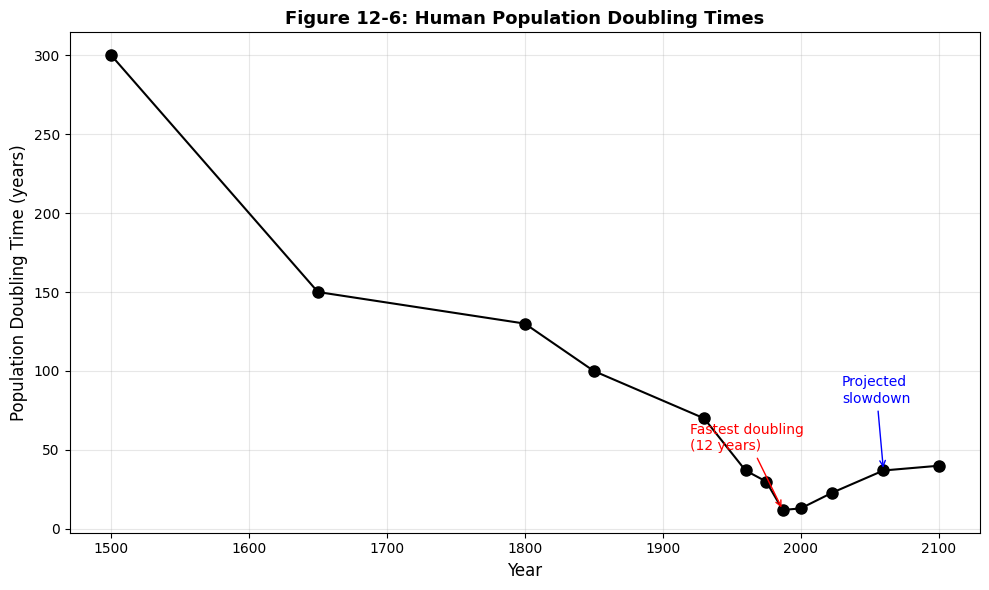

Figure 12-6: Population doubling time data.


In [12]:

# Polynomial Regression: Human Population Doubling Times

# Dataset: How many years it took for the world population to double.
# Source: Based on historical data and UN projections.

# Year when each doubling was reached (approximate)
year = np.array([1500, 1650, 1800, 1850, 1930, 1960, 1975, 1987, 2000, 2023, 2060, 2100])

# Time in years it took to double from the previous milestone
doubleTime = np.array([300, 150, 130, 100, 70, 37, 30, 12, 13, 23, 37, 40])

N = len(year)
print(f"Number of data points: {N}")
print(f"Year range: {year[0]} to {year[-1]}")
print(f"Doubling time range: {doubleTime.min()} to {doubleTime.max()} years")
print()

# Plot the data
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(year, doubleTime, 'ko-', markersize=8, linewidth=1.5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Population Doubling Time (years)', fontsize=12)
ax.set_title('Figure 12-6: Human Population Doubling Times', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Annotate key points
ax.annotate('Fastest doubling\n(12 years)', xy=(1987, 12), xytext=(1920, 50),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='red'),
            color='red')
ax.annotate('Projected\nslowdown', xy=(2060, 37), xytext=(2030, 80),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='blue'),
            color='blue')

plt.tight_layout()
plt.show()
print("Figure 12-6: Population doubling time data.")

### Understanding the Population Doubling Data (Figure 12-6)

This dataset tells a fascinating story about human history. Each point represents the number of years it took for the world's population to double.

From $1500$ to roughly $1987$, the doubling time *decreased* -- from $300$ years down to just $12$ years. This acceleration happened because population growth is (approximately) exponential: more people $\to$ more births $\to$ even more people. Advances in agriculture, medicine, and sanitation dramatically reduced mortality rates while birth rates remained high.

But around $1987$, something changed. The doubling time started *increasing* again. This reflects the global demographic transition: as countries industrialize, birth rates fall. The projected values for $2060$ and $2100$ suggest doubling times of $37{-}40$ years -- a significant slowdown.

**Why polynomial regression fits this data well:** The data has a clear **U-shape** (or more precisely, a shape that decreases then increases). A straight line cannot capture this -- it would show only a constant trend. A polynomial of degree $\geq 2$ can model the curvature. We will use a **third-order** polynomial (degree $3$), which has four coefficients and can model both the curvature and any asymmetry in the U-shape.

Polynomial design matrix (Vandermonde matrix):
  Shape: (12, 4)  (12 observations x 4 regressors)
  Column 0: x^0 = [1, 1, ..., 1]  (intercept)
  Column 1: x^1 = [1500, 1650, ..., 2100]
  Column 2: x^2 = [2250000, 2722500, ..., 4410000]
  Column 3: x^3 = [3375000000, 4492125000, ..., 9261000000]

Beta coefficients:
  beta_0 (x^0): 8.613661e+02
  beta_1 (x^1): 8.088585e-01
  beta_2 (x^2): -1.338755e-03
  beta_3 (x^3): 3.637738e-07

R-squared: 0.9405
  -> The model explains 94.1% of the variance.


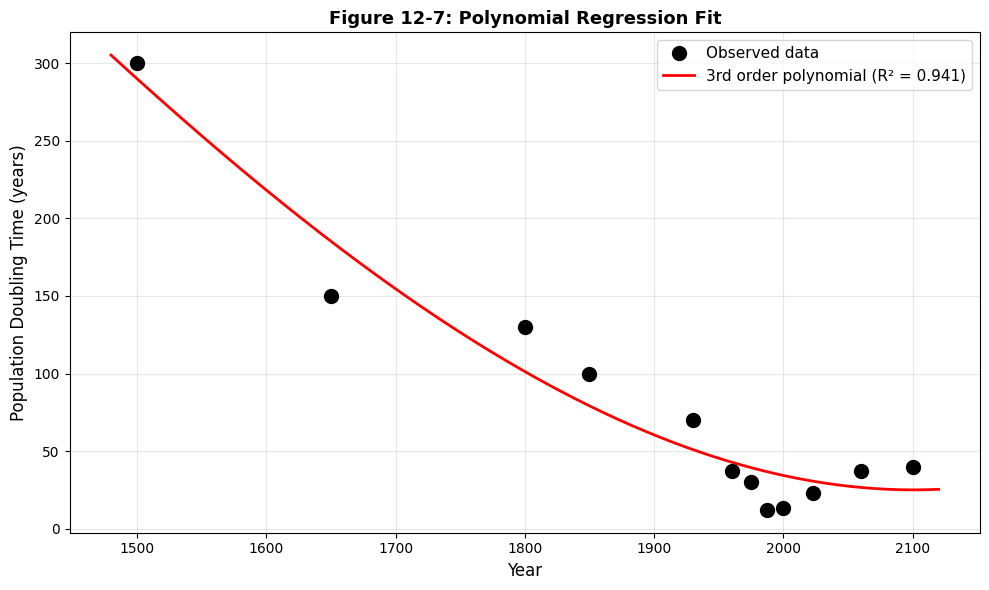

Figure 12-7: Third-order polynomial fit to population doubling data.


In [13]:

# Fit a third-order polynomial regression

# Method 1: Build the design matrix manually (for understanding)
poly_order = 3
X_poly = np.zeros((N, poly_order + 1))
for i in range(poly_order + 1):
    X_poly[:, i] = np.array(year)**i

print("Polynomial design matrix (Vandermonde matrix):")
print(f"  Shape: {X_poly.shape}  ({N} observations x {poly_order+1} regressors)")
print(f"  Column 0: x^0 = [1, 1, ..., 1]  (intercept)")
print(f"  Column 1: x^1 = [{year[0]}, {year[1]}, ..., {year[-1]}]")
print(f"  Column 2: x^2 = [{year[0]**2}, {year[1]**2}, ..., {year[-1]**2}]")
print(f"  Column 3: x^3 = [{year[0]**3}, {year[1]**3}, ..., {year[-1]**3}]")
print()

# Solve using least squares
result_poly = np.linalg.lstsq(X_poly, doubleTime, rcond=None)
beta_poly = result_poly[0]

print("Beta coefficients:")
for i, b in enumerate(beta_poly):
    print(f"  beta_{i} (x^{i}): {b:.6e}")

# Compute predicted values
yHat_poly = X_poly @ beta_poly

# R-squared
SS_res_poly = np.sum((doubleTime - yHat_poly)**2)
SS_tot_poly = np.sum((doubleTime - np.mean(doubleTime))**2)
R2_poly = 1 - SS_res_poly / SS_tot_poly
print(f"\nR-squared: {R2_poly:.4f}")
print(f"  -> The model explains {R2_poly*100:.1f}% of the variance.")

# Plot with polynomial fit
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(year, doubleTime, 'ko', markersize=10, label='Observed data', zorder=5)

# Dense x values for smooth curve
x_smooth = np.linspace(year.min()-20, year.max()+20, 300)
X_smooth = np.column_stack([x_smooth**i for i in range(poly_order+1)])
y_smooth = X_smooth @ beta_poly

ax.plot(x_smooth, y_smooth, 'r-', linewidth=2, label=f'3rd order polynomial (R² = {R2_poly:.3f})')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Population Doubling Time (years)', fontsize=12)
ax.set_title('Figure 12-7: Polynomial Regression Fit', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Figure 12-7: Third-order polynomial fit to population doubling data.")

### Why the Polynomial Works So Well

With an $R^2 = 0.941$, the third-order polynomial captures **94.1%** of the variance in population doubling times -- a dramatic improvement over our bike rental model.

The polynomial model is:

$$\hat{y} = \beta_0 + \beta_1 \cdot x + \beta_2 \cdot x^2 + \beta_3 \cdot x^3$$

where $x$ is the year and $\hat{y}$ is the predicted doubling time. The coefficients are extremely small for the higher-order terms because the year values are large (around $1500{-}2100$), so $x^3$ produces very large numbers that must be scaled down by a tiny $\beta_3$.

The curve shows the characteristic behavior: decreasing doubling time through the 20th century (the acceleration of population growth) followed by a projected increase (the demographic transition). The cubic polynomial captures the asymmetry of this pattern -- the decrease is steeper than the projected increase.

**NumPy convenience functions:** For polynomial fitting, NumPy provides `np.polyfit()` and `np.polyval()` which handle the design matrix construction internally. However, building the Vandermonde matrix manually (as we did above) is important for understanding what these functions do under the hood.

In [14]:

# Using NumPy's built-in polynomial functions

# np.polyfit returns coefficients in DESCENDING order (highest power first)
beta_np = np.polyfit(year, doubleTime, 3)
yHat_np = np.polyval(beta_np, year)

print("Coefficients from np.polyfit (highest power first):")
for i, b in enumerate(beta_np):
    print(f"  x^{3-i}: {b:.6e}")

print(f"\nPredicted values match? {np.allclose(yHat_poly, yHat_np)}")

# Compare residuals
residuals = doubleTime - yHat_np
print(f"\nResiduals (observed - predicted):")
for i in range(len(year)):
    print(f"  Year {year[i]:4d}: observed = {doubleTime[i]:3d}, predicted = {yHat_np[i]:6.1f}, residual = {residuals[i]:+6.1f}")

Coefficients from np.polyfit (highest power first):
  x^3: 3.637738e-07
  x^2: -1.338755e-03
  x^1: 8.088585e-01
  x^0: 8.613661e+02

Predicted values match? True

Residuals (observed - predicted):
  Year 1500: observed = 300, predicted =  290.2, residual =   +9.8
  Year 1650: observed = 150, predicted =  185.3, residual =  -35.3
  Year 1800: observed = 130, predicted =  101.3, residual =  +28.7
  Year 1850: observed = 100, predicted =   79.1, residual =  +20.9
  Year 1930: observed =  70, predicted =   50.9, residual =  +19.1
  Year 1960: observed =  37, predicted =   42.8, residual =   -5.8
  Year 1975: observed =  30, predicted =   39.3, residual =   -9.3
  Year 1987: observed =  12, predicted =   36.7, residual =  -24.7
  Year 2000: observed =  13, predicted =   34.3, residual =  -21.3
  Year 2023: observed =  23, predicted =   30.5, residual =   -7.5
  Year 2060: observed =  37, predicted =   26.5, residual =  +10.5
  Year 2100: observed =  40, predicted =   25.0, residual =  +15.

### Manual vs. NumPy Polynomial Fitting

Both approaches produce the same predicted values, confirming that our manual Vandermonde matrix construction is correct. Note that `np.polyfit` returns coefficients in **descending** order ($\beta_3, \beta_2, \beta_1, \beta_0$) while our manual approach used ascending order. This is a common source of confusion -- always check the documentation!

The residuals show that the model fits most points quite closely, with the largest deviations occurring at the endpoints and at the minimum (around 1987). This is typical of polynomial fits -- they do well in the interior of the data range but can extrapolate poorly beyond the observed range.

**A word of caution about extrapolation:** Cubic polynomials grow as $x^3$, so predicting far beyond $2100$ would give wildly unreasonable results. Polynomial models are interpolators, not extrapolators. For long-range forecasting, domain-specific models (like demographic models with birth/death rate parameters) are more appropriate.

---
## Grid Search to Find Model Parameters

Least squares provides an **analytic** (closed-form) solution to the model-fitting problem. You write down the formula, plug in the data, and get the answer in one step. This is fast, exact, and deterministic.

But not all models have analytic solutions. When they don't, we need **numerical optimization** methods. One of the simplest is **grid search**.

**The grid search algorithm:**

$$\text{1. Define a grid of candidate parameter values}$$
$$\text{2. For each point on the grid, compute the model's error on the data}$$
$$\text{3. Select the grid point with the smallest error}$$

Think of it like trying on shoes in a store. You cannot try every possible shoe size (continuous), so you try the available sizes (a discrete grid) and pick the one that fits best. If the store only carries whole sizes and your true size is $9.5$, the best you can do is $9$ or $10$ -- close, but not perfect.

**Grid search has two critical parameters:**

**Range:** The min and max of each parameter dimension. If the true optimal value lies outside your grid range, you will never find it. Like searching for your keys in the living room when they are in the kitchen.

**Resolution:** The spacing between grid points. Finer resolution gives better results but takes more computation. An $n \times n$ grid requires $n^2$ model evaluations. A $100 \times 100$ grid takes $10{,}000$ evaluations; a $1000 \times 1000$ grid takes $1{,}000{,}000$.

The error metric we will use is the **Sum of Squared Errors (SSE)**:

$$\text{SSE}(\boldsymbol{\beta}) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$$

This is the same objective that least squares minimizes analytically.

Grid 1: x = [-2 -1  0  1  2]   y = [4 1 0 1 4]
  Best: x = 0, y = 0  (TRUE minimum)

Grid 2: x = [-2.  -0.5  1.   2.5]   y = [4.   0.25 1.   6.25]
  Best: x = -0.5, y = 0.25  (close but not exact)

Grid 3: x = [-1000  -990  -980  -970]   y = [1000000  980100  960400  940900]
  Best: x = -970, y = 940900  (TERRIBLE -- wrong range!)


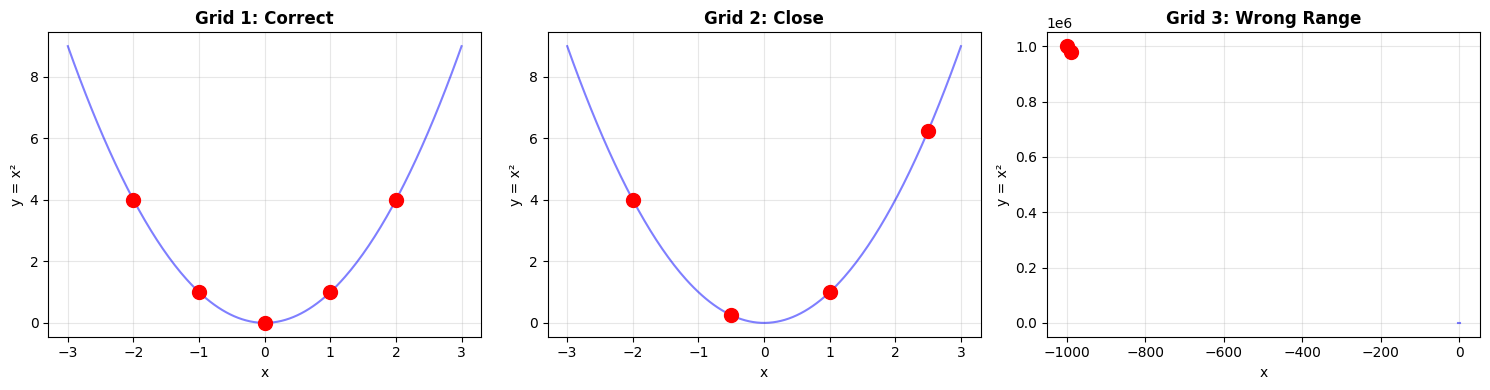

Grid search quality depends on BOTH range and resolution.


In [15]:

# Grid Search: Simple example with y = x^2

# True minimum: x = 0, y = 0

# Grid 1: Good range and resolution
grid1 = np.array([-2, -1, 0, 1, 2])
y_grid1 = grid1**2
best1_idx = np.argmin(y_grid1)
print("Grid 1: x =", grid1, "  y =", y_grid1)
print(f"  Best: x = {grid1[best1_idx]}, y = {y_grid1[best1_idx]}  (TRUE minimum)")

# Grid 2: Good range, but minimum missed
grid2 = np.array([-2, -0.5, 1, 2.5])
y_grid2 = grid2**2
best2_idx = np.argmin(y_grid2)
print(f"\nGrid 2: x =", grid2, "  y =", y_grid2)
print(f"  Best: x = {grid2[best2_idx]}, y = {y_grid2[best2_idx]}  (close but not exact)")

# Grid 3: Wrong range entirely
grid3 = np.array([-1000, -990, -980, -970])
y_grid3 = grid3**2
best3_idx = np.argmin(y_grid3)
print(f"\nGrid 3: x =", grid3, "  y =", y_grid3)
print(f"  Best: x = {grid3[best3_idx]}, y = {y_grid3[best3_idx]}  (TERRIBLE -- wrong range!)")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_true = np.linspace(-3, 3, 200)
for ax, grid_x, grid_y, title in zip(axes,
    [grid1, grid2, grid3[:2]],  # show only 2 points of grid3 for scale
    [y_grid1, y_grid2, y_grid3[:2]],
    ['Grid 1: Correct', 'Grid 2: Close', 'Grid 3: Wrong Range']):
    ax.plot(x_true, x_true**2, 'b-', linewidth=1.5, alpha=0.5)
    ax.plot(grid_x, grid_y, 'ro', markersize=10, zorder=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y = x²')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Grid search quality depends on BOTH range and resolution.")

### The Three Faces of Grid Search

These three examples illustrate the fundamental limitation of grid search:

**Grid 1** happens to include $x = 0$, so it finds the exact minimum. This is lucky -- if the grid were $(-2, -0.5, 0.5, 2)$, the best would be $x = -0.5$ with $y = 0.25$.

**Grid 2** does not include $x = 0$, so the best it can do is $x = -0.5$. The answer is "kind of correct" in the sense that $-0.5$ is the best option *within the grid*. Grid search always finds the grid-optimal solution, but that may not be the globally optimal solution.

**Grid 3** has a completely wrong range. All values are far from zero, so the "best" answer ($x = -970$) is absurd. This happens when you have no prior knowledge about where the optimal parameters lie.

**The lesson:** Grid search is only as good as your grid design. In practice, a common strategy is to start with a coarse grid over a wide range, identify the promising region, then refine with a finer grid around that region. This is called **coarse-to-fine search**.

Data: 30 students
  Courses taken: 1 to 10
  Satisfaction: 0.7 to 11.0

Analytic (least squares) solution:
  Intercept = 1.6170
  Slope     = 0.8855

Grid search solution (200x200 = 40,000 evaluations):
  Intercept = 1.6181
  Slope     = 0.8894
  Min SSE   = 47.9247

Analytic SSE = 47.9046
Grid SSE     = 47.9247
Difference   = 0.020099


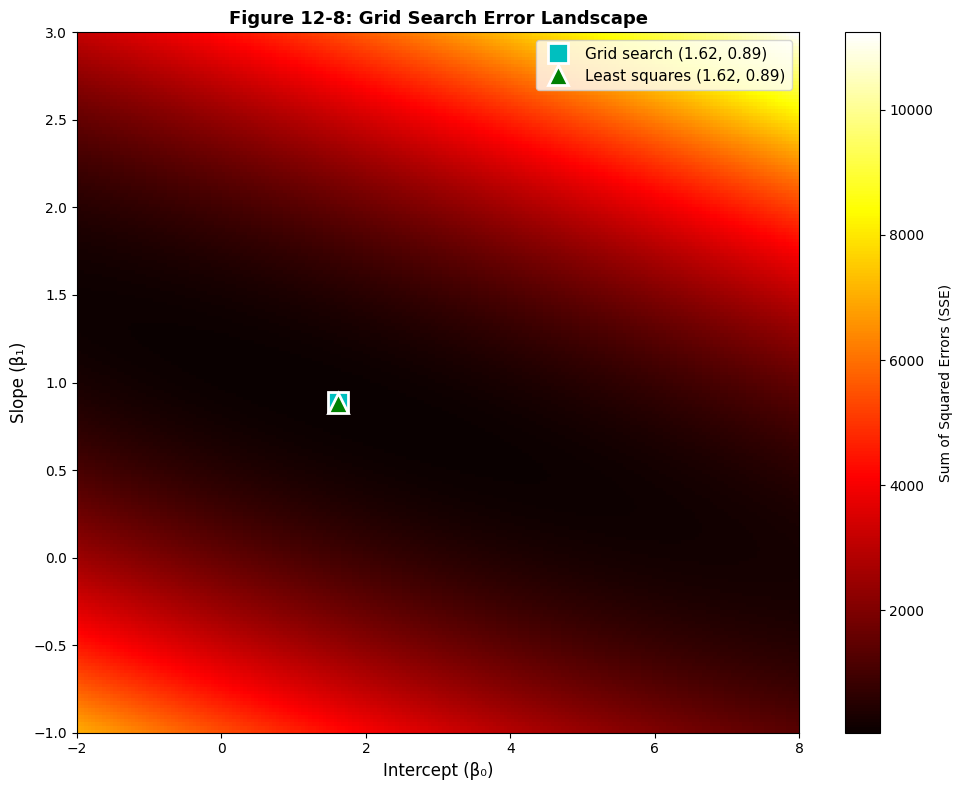

Figure 12-8: Darker regions = lower SSE = better fit.


In [16]:

# 2D Grid Search on the "Happy Student" Dataset

# Create fake data: students who take more courses report higher satisfaction
np.random.seed(42)
n_students = 30
courses = np.random.randint(1, 11, n_students)  # 1-10 courses
satisfaction = 2.5 + 0.8 * courses + np.random.normal(0, 1.5, n_students)  # true: intercept=2.5, slope=0.8

print(f"Data: {n_students} students")
print(f"  Courses taken: {courses.min()} to {courses.max()}")
print(f"  Satisfaction: {satisfaction.min():.1f} to {satisfaction.max():.1f}")

# Step 1: Analytic solution via least squares
X_happy = np.column_stack([np.ones(n_students), courses])
beta_analytic = np.linalg.lstsq(X_happy, satisfaction, rcond=None)[0]
print(f"\nAnalytic (least squares) solution:")
print(f"  Intercept = {beta_analytic[0]:.4f}")
print(f"  Slope     = {beta_analytic[1]:.4f}")

# Step 2: Grid search
# Define grids for intercept and slope
intercept_grid = np.linspace(-2, 8, 200)   # 200 values
slope_grid     = np.linspace(-1, 3, 200)    # 200 values

# Compute SSE for every (intercept, slope) combination
SSE_matrix = np.zeros((len(slope_grid), len(intercept_grid)))

for i, s in enumerate(slope_grid):
    for j, b in enumerate(intercept_grid):
        predictions = b + s * courses
        SSE_matrix[i, j] = np.sum((satisfaction - predictions)**2)

# Find the grid minimum
min_idx = np.unravel_index(SSE_matrix.argmin(), SSE_matrix.shape)
best_slope = slope_grid[min_idx[0]]
best_intercept = intercept_grid[min_idx[1]]

print(f"\nGrid search solution ({len(intercept_grid)}x{len(slope_grid)} = {len(intercept_grid)*len(slope_grid):,} evaluations):")
print(f"  Intercept = {best_intercept:.4f}")
print(f"  Slope     = {best_slope:.4f}")
print(f"  Min SSE   = {SSE_matrix.min():.4f}")

# Analytic SSE
predictions_analytic = X_happy @ beta_analytic
SSE_analytic = np.sum((satisfaction - predictions_analytic)**2)
print(f"\nAnalytic SSE = {SSE_analytic:.4f}")
print(f"Grid SSE     = {SSE_matrix.min():.4f}")
print(f"Difference   = {SSE_matrix.min() - SSE_analytic:.6f}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Show SSE landscape
im = ax.imshow(SSE_matrix, extent=[intercept_grid[0], intercept_grid[-1],
               slope_grid[0], slope_grid[-1]],
               aspect='auto', origin='lower', cmap='hot')
plt.colorbar(im, ax=ax, label='Sum of Squared Errors (SSE)')

# Mark solutions
ax.plot(best_intercept, best_slope, 'cs', markersize=15,
        markeredgecolor='white', markeredgewidth=2, label=f'Grid search ({best_intercept:.2f}, {best_slope:.2f})')
ax.plot(beta_analytic[0], beta_analytic[1], 'g^', markersize=15,
        markeredgecolor='white', markeredgewidth=2, label=f'Least squares ({beta_analytic[0]:.2f}, {beta_analytic[1]:.2f})')

ax.set_xlabel('Intercept (β₀)', fontsize=12)
ax.set_ylabel('Slope (β₁)', fontsize=12)
ax.set_title('Figure 12-8: Grid Search Error Landscape', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()
print("Figure 12-8: Darker regions = lower SSE = better fit.")

### Grid Search vs. Least Squares -- The Verdict (Figure 12-8)

The error landscape (Figure 12-8) shows the SSE for every combination of intercept and slope on our $200 \times 200$ grid. The darkest region (lowest SSE) forms an elongated valley -- the parameters are somewhat correlated, meaning that many (intercept, slope) combinations give similar fits.

The cyan square (grid search optimum) and green triangle (least squares solution) are close but not identical. The grid search finds the best solution *on the grid*, while least squares finds the globally optimal solution in continuous parameter space.

**Key takeaways from this comparison:**

| Property | Least Squares | Grid Search |
|:---|:---|:---|
| Solution type | Exact (analytic) | Approximate (grid-dependent) |
| Computation | Single matrix operation: $O(np^2)$ | Exhaustive: $O(G^p)$ where $G$ = grid size, $p$ = parameters |
| Applicability | Linear models only | Any model (linear or nonlinear) |
| Deterministic? | Yes | Yes (given the same grid) |
| Guarantees | Global optimum | Grid optimum only |

**When to use each:**

Use **least squares** whenever possible -- it is faster, exact, and more reliable. Use **grid search** when the model is nonlinear and no analytic solution exists. In modern machine learning, grid search is commonly used for **hyperparameter tuning** -- selecting learning rates, regularization strengths, network architectures, and other design choices that cannot be optimized by gradient descent.

**Computational scaling:** Our grid had $200 \times 200 = 40{,}000$ evaluations for just $2$ parameters. For $p$ parameters with $G$ grid points each, we need $G^p$ evaluations. With $p = 10$ parameters and $G = 20$, that is $20^{10} \approx 10^{13}$ evaluations -- completely infeasible. This is the **curse of dimensionality**, and it is why more sophisticated methods like **random search**, **Bayesian optimization**, and **gradient descent** are preferred for high-dimensional optimization.

---
## Summary

This chapter demonstrated that linear algebra is not just an abstract mathematical subject -- it is the computational engine behind real-world data analysis. Here are the key takeaways, organized by concept:

**Visual inspection of data** is the essential first step before any analysis. The bike rental scatter plots immediately revealed the seasonal pattern and the sparsity of rainfall. No algorithm can substitute for a careful look at your data.

**The design matrix** $\mathbf{X}$ is the bridge between your data and your model. Constructing it correctly -- including the intercept column, handling categorical variables, and checking for linear dependencies -- is a skill that separates good data scientists from great ones.

**Multicollinearity** occurs when columns of $\mathbf{X}$ are linearly dependent, making $(\mathbf{X}^T\mathbf{X})$ singular. This is a fundamental concept: in linear algebra we call it "rank deficiency," in statistics we call it "multicollinearity," but it is the same mathematical phenomenon. The solution involves either fixing the model or applying **regularization**.

**Regularization** shifts the design matrix by adding $\gamma \|\mathbf{X}\|_F^2 \mathbf{I}$ to the diagonal of $\mathbf{X}^T\mathbf{X}$. This makes the matrix invertible, reduces the condition number, and produces solutions that generalize better to new data. The parameter $\gamma$ controls the bias-variance tradeoff.

**Polynomial regression** extends linear regression to fit curves by constructing a Vandermonde design matrix with powers of $x$. Despite fitting nonlinear shapes, it is still "linear" in the parameters and can be solved using the same least squares machinery.

**Grid search** is a brute-force optimization method that evaluates every point on a discrete grid. While simple and universally applicable, it is limited by the curse of dimensionality and always produces approximate solutions. Least squares is superior when applicable.

**The overarching message:** Understanding linear algebra deeply -- rank, invertibility, condition numbers, projections -- gives you the tools to diagnose problems, select appropriate methods, and build better models. The math is not separate from the practice; it *is* the practice.